In [8]:
#hand tracking using MeidaPipe
#pip install mediapipe
import cv2
import mediapipe as mp

mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

# For webcam input:
cap = cv2.VideoCapture(0)
frameWidth = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
frameHeight = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

with mp_hands.Hands(
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7) as hands:

  while cap.isOpened():
    success, image = cap.read()
    if not success:
      print("Ignoring empty camera frame.")
      # If loading a video, use 'break' instead of 'continue'.
      continue

    # Flip the image horizontally for a later selfie-view display, and convert
    # the BGR image to RGB.
    image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)
    # To improve performance, optionally mark the image as not writeable to
    # pass by reference.
    image.flags.writeable = False
    results = hands.process(image)

    # Draw the hand annotations on the image.
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    if results.multi_hand_landmarks:
      for hand_landmarks in results.multi_hand_landmarks:
        #mp_drawing.draw_landmarks(
        #    image, hand_landmarks, mp_hands.HAND_CONNECTIONS)
        for point in mp_hands.HandLandmark:
            normalizedLandmark = hand_landmarks.landmark[point]
            pixelCoordinatesLandmark = mp_drawing._normalized_to_pixel_coordinates(normalizedLandmark.x, 
                                                            normalizedLandmark.y, frameWidth, frameHeight)
            cv2.circle(image, pixelCoordinatesLandmark, 5, (0, 255, 0), -1)
            print(point, pixelCoordinatesLandmark)
    cv2.imshow('MediaPipe Hands', image)
    c = cv2.waitKey(1)
    if c == 27:
        break
cap.release()
cv2.destroyAllWindows()

0 None
1 (587, 412)
2 (534, 368)
3 (500, 319)
4 (463, 283)
5 (574, 280)
6 (550, 208)
7 (540, 159)
8 (533, 118)
9 (621, 267)
10 (622, 186)
11 (623, 129)
12 (625, 84)
13 None
14 None
15 None
16 None
17 None
18 None
19 None
20 None
0 None
1 (576, 399)
2 (520, 352)
3 (485, 303)
4 (447, 264)
5 (557, 265)
6 (535, 190)
7 (524, 143)
8 (516, 100)
9 (605, 250)
10 (601, 168)
11 (598, 109)
12 (597, 62)
13 None
14 None
15 None
16 None
17 None
18 None
19 None
20 None
0 None
1 (576, 404)
2 (519, 351)
3 (483, 301)
4 (444, 263)
5 (556, 264)
6 (532, 188)
7 (521, 140)
8 (512, 97)
9 (604, 250)
10 (599, 165)
11 (596, 105)
12 (594, 57)
13 None
14 None
15 None
16 None
17 None
18 None
19 None
20 None
0 None
1 (568, 403)
2 (510, 350)
3 (473, 297)
4 (434, 258)
5 (545, 261)
6 (521, 186)
7 (508, 140)
8 (500, 98)
9 (590, 246)
10 (584, 162)
11 (580, 105)
12 (577, 58)
13 (631, 248)
14 (636, 168)
15 (636, 117)
16 (635, 71)
17 None
18 None
19 None
20 None
0 (623, 406)
1 (539, 382)
2 (481, 330)
3 (442, 278)
4 (402, 242

In [5]:
#pose tracking using MeidaPipe
#pip install mediapipe
import cv2
import mediapipe as mp
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# For webcam input:
cap = cv2.VideoCapture(0)
with mp_pose.Pose(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5) as pose:
  while cap.isOpened():
    success, image = cap.read()
    if not success:
      print("Ignoring empty camera frame.")
      # If loading a video, use 'break' instead of 'continue'.
      continue

    # Flip the image horizontally for a later selfie-view display, and convert
    # the BGR image to RGB.
    image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)
    # To improve performance, optionally mark the image as not writeable to
    # pass by reference.
    image.flags.writeable = False
    results = pose.process(image)

    # Draw the pose annotation on the image.
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    mp_drawing.draw_landmarks(
        image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
    cv2.imshow('MediaPipe Pose', image)
    if cv2.waitKey(5) & 0xFF == 27:
      break
cap.release()
cv2.destroyAllWindows()

ModuleNotFoundError: No module named 'mediapipe'

###### %%writefile test
## Practice MediaPipe
1. Input continuous BGR images from webcam.
2. Use <i>MediaPipe()</i> to detect and track one of your hands.
3. Obtain the positions of 21 HandLandmarks.
4. Design an algorithm to recognize three hand gestures of Rock, Scissor, Paper.
5. Use <i>cv2.putText()</i> to write the type of the recognized hand gesture on the upper left corner.
6. Show your output images.
7. Upload your Jupyter code file (*.ipynb)
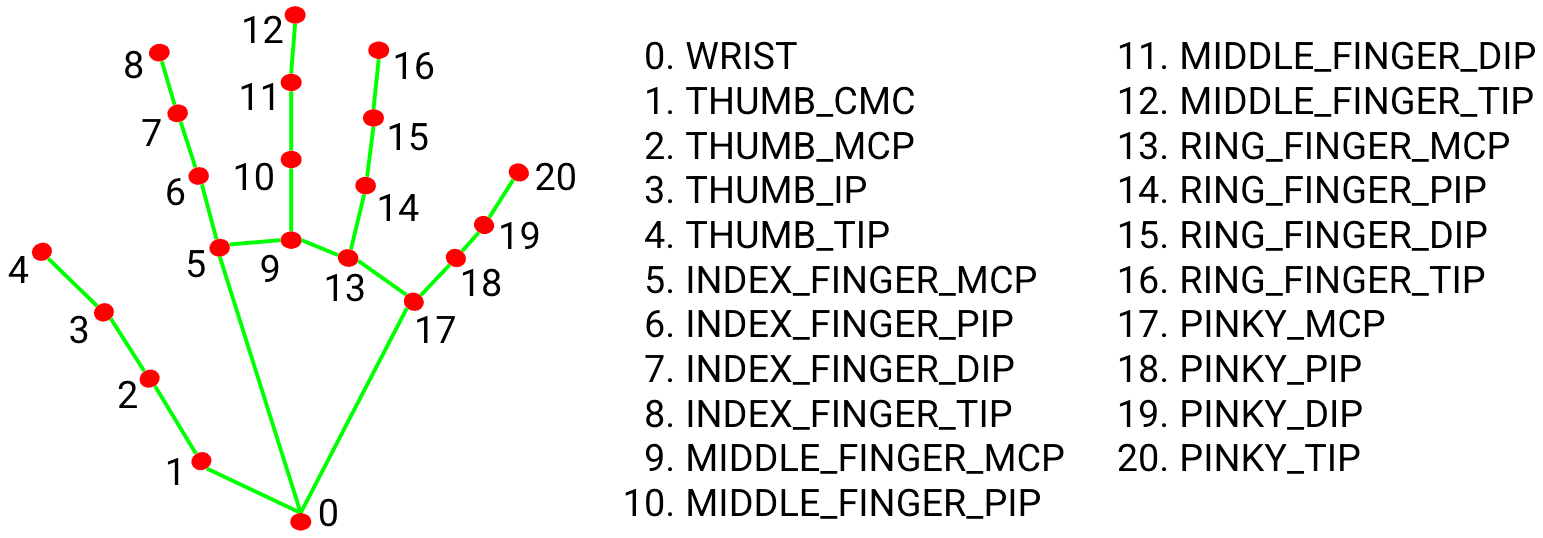

In [1]:
!python --version

Python 3.12.12


In [2]:
import mediapipe as mp
print(mp.__version__)

0.10.21


In [ ]:
# in hand_gestures to test the idea
'''
    if landmarks[8]:
        x1, y1 = landmarks[8]
    else:
        x1, y1 = (0, 0)
    if landmarks[6]:
        x2, y2 = landmarks[6]
    else:
        x2, y2 = (0, 0)
    if landmarks[5]:
        x3, y3 = landmarks[5]
    else:
        x3, y3 = (0, 0)
    tip2pip[1] = math.sqrt(abs((x1 - x3)**2 + (y1 - y3)**2))
    dip2pip[1] = math.sqrt(abs((x2 - x3)**2 + (y2 - y3)**2))
    
    img = cv2.arrowedLine(
            img, 
            (x1, y1), 
            (x3, y3), 
            (255, 255, 255), 
            5,                  # thickness=1 (整數)
            cv2.LINE_8,         # line_type (預設值, 確保是整數)
            0,                  # shift (預設值, 確保是整數)
            tipLength=0.15      # tipLength (浮點數)
        )
    img = cv2.arrowedLine(
            img, 
            (x2, y2), 
            (x3, y3), 
            (255, 255, 255), 
            5,                  # thickness=1 (整數)
            cv2.LINE_8,         # line_type (預設值, 確保是整數)
            0,                  # shift (預設值, 確保是整數)
            tipLength=0.15      # tipLength (浮點數)
        )
    print(tip2pip[1] , dip2pip[1])
    '''

In [2]:
#hand tracking using MeidaPipe
#pip install mediapipe
import cv2
import mediapipe as mp
import math
import numpy as np

mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

# For webcam input:
cap = cv2.VideoCapture(0)
frameWidth = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
frameHeight = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

TIP_IDS = [4, 8, 12, 16, 20]
DIP_IDS = [2, 6, 10, 14, 18]
PIP_IDS = [1, 5, 9, 13, 17]

def same_direction(v1, v2, threshold=0.80):
    v1 = np.array(v1)
    v2 = np.array(v2)
    mag1 = np.linalg.norm(v1)
    mag2 = np.linalg.norm(v2)
    if mag1 == 0 or mag2 == 0:
        return False
    dot_product = np.dot(v1, v2)
    cosine_similarity = dot_product / (mag1 * mag2)
    return cosine_similarity >= threshold

def hand_gestures(img, landmarks):
    tip2pip = {}
    dip2pip = {}


    for i in range(5):
        if landmarks[4 + 4*i]:
            x1, y1 = landmarks[4 + 4*i]
        else:
            x1, y1 = (0, 0)
        if landmarks[2+ 4*i]:
            x2, y2 = landmarks[2+ 4*i]
        else:
            x2, y2 = (0, 0)
        if landmarks[1+ 4*i]:
            x3, y3 = landmarks[1+ 4*i]
        else:
            x3, y3 = (0, 0)
        tip2pip[i] = ((x1 - x3), (y1 - y3))
        dip2pip[i] = ((x2 - x3), (y2 - y3))

    if (not same_direction(tip2pip[0], dip2pip[0]) and
        same_direction(tip2pip[1], dip2pip[1]) and
        same_direction(tip2pip[2], dip2pip[2]) and
        not same_direction(tip2pip[3], dip2pip[3]) and
        not same_direction(tip2pip[4], dip2pip[4])):
        return "Scissor" # Scissor
        
    elif (not same_direction(tip2pip[0], dip2pip[0]) and
        not same_direction(tip2pip[1], dip2pip[1]) and
        not same_direction(tip2pip[2], dip2pip[2]) and
        not same_direction(tip2pip[3], dip2pip[3]) and
        not same_direction(tip2pip[4], dip2pip[4])):
        return "Rock" # Rock

    elif (same_direction(tip2pip[0], dip2pip[0]) and
        same_direction(tip2pip[1], dip2pip[1]) and
        same_direction(tip2pip[2], dip2pip[2]) and
        same_direction(tip2pip[3], dip2pip[3]) and
        same_direction(tip2pip[4], dip2pip[4])):
        return "Paper" # Paper
    else:
        return "NaN"


with mp_hands.Hands(
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7) as hands:

  while cap.isOpened():
    success, image = cap.read()
    if not success:
      print("Ignoring empty camera frame.")
      # If loading a video, use 'break' instead of 'continue'.
      continue

    text = "NaN"
    pixelCoordinatesLandmark = {}
      
    # Flip the image horizontally for a later selfie-view display, and convert
    # the BGR image to RGB.
    image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)
    # To improve performance, optionally mark the image as not writeable to
    # pass by reference.
    image.flags.writeable = False
    results = hands.process(image)

    # Draw the hand annotations on the image.
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                image, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            for point in mp_hands.HandLandmark:
                normalizedLandmark = hand_landmarks.landmark[point]
                pixelCoordinatesLandmark[point] = mp_drawing._normalized_to_pixel_coordinates(normalizedLandmark.x, 
                                                                normalizedLandmark.y, frameWidth, frameHeight)
                #cv2.circle(image, pixelCoordinatesLandmark[point], 5, (0, 255, 0), -1)
                #print(point, pixelCoordinatesLandmark[point])
        text = hand_gestures(image, pixelCoordinatesLandmark)
    cv2.putText(image, text, (0, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
    cv2.imshow('MediaPipe Hands', image)
    c = cv2.waitKey(1)
    if c == 27:
        break
cap.release()
cv2.destroyAllWindows()

I0000 00:00:1765371246.140240  127071 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1765371246.143652  127130 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (ADL-N)
W0000 00:00:1765371246.172653  127127 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765371246.189961  127125 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


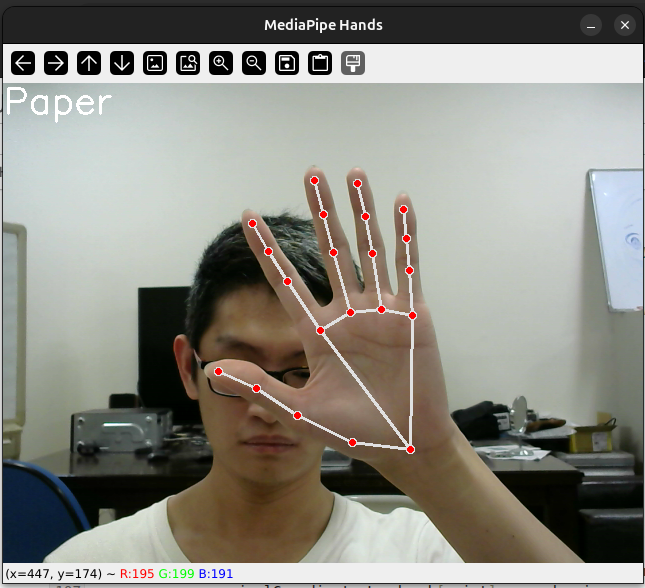
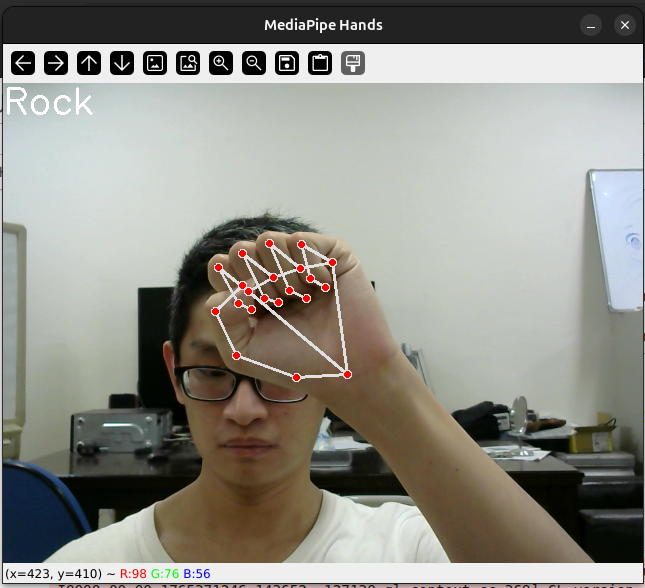
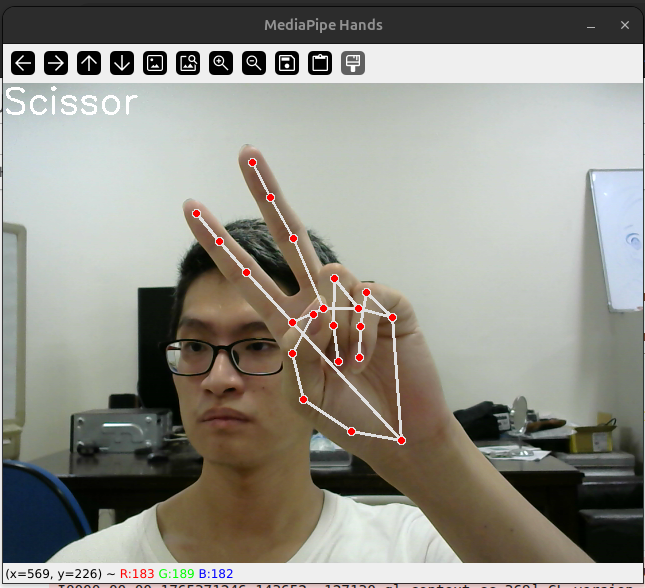